In [7]:
from transformers import ViTForImageClassification, ViTImageProcessor

save_dir = "./vit_calligraphy_best"

processor = ViTImageProcessor.from_pretrained(save_dir)
model = ViTForImageClassification.from_pretrained(save_dir)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [8]:
from pathlib import Path
from collections import Counter
import random
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

In [9]:
# 加载 classification 数据（calli-kaggle）
data_root = Path("calli-kaggle/data/data")
if not data_root.exists():
    raise FileNotFoundError(f"未找到数据目录: {data_root.resolve()}")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def load_split(split_name: str):
    split_dir = data_root / split_name
    if not split_dir.exists():
        raise FileNotFoundError(f"未找到 split 目录: {split_dir}")

    class_names = sorted([p.name for p in split_dir.iterdir() if p.is_dir()])
    class_to_idx = {name: i for i, name in enumerate(class_names)}

    samples = []
    for class_name in class_names:
        class_dir = split_dir / class_name
        for p in class_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                samples.append((str(p), class_to_idx[class_name], class_name))

    return class_names, class_to_idx, samples

train_classes, class_to_idx, train_samples = load_split("train")
test_classes, _, test_samples = load_split("test")

# train/test 类别一致性检查
if train_classes != test_classes:
    print("警告: train 和 test 的类别列表不一致")
else:
    print(f"类别数: {len(train_classes)}")
    print(f"类别名: {train_classes}")

train_counts = Counter([label_name for _, _, label_name in train_samples])
test_counts = Counter([label_name for _, _, label_name in test_samples])

print(f"train 样本数: {len(train_samples)}")
print(f"test 样本数: {len(test_samples)}")

print("\n各类别样本数（train / test）:")
for c in train_classes:
    print(f"{c:>6}: {train_counts.get(c, 0):>4} / {test_counts.get(c, 0):>4}")

# 随机查看几条样本路径
preview_n = min(5, len(train_samples))
print("\ntrain 样本示例:")
for path, label_idx, label_name in random.sample(train_samples, k=preview_n):
    print(f"label={label_idx:>2} ({label_name}) | {path}")

# 如果你后续要喂给模型，可直接使用：
X_train = [s[0] for s in train_samples]
y_train = [s[1] for s in train_samples]
X_test = [s[0] for s in test_samples]
y_test = [s[1] for s in test_samples]

print("\n已生成: X_train, y_train, X_test, y_test, class_to_idx")

类别数: 20
类别名: ['bdsr', 'csl', 'fwq', 'gj', 'htj', 'hy', 'lgq', 'lqs', 'lx', 'mf', 'mzd', 'oyx', 'sgt', 'shz', 'smh', 'wxz', 'wzm', 'yyr', 'yzq', 'zmf']
train 样本数: 84022
test 样本数: 21007

各类别样本数（train / test）:
  bdsr: 1588 /  397
   csl:  860 /  215
   fwq: 5410 / 1353
    gj: 5410 / 1353
   htj: 5371 / 1343
    hy: 2665 /  666
   lgq: 5410 / 1353
   lqs: 5406 / 1351
    lx: 5410 / 1353
    mf: 5410 / 1353
   mzd: 5410 / 1353
   oyx: 2808 /  702
   sgt: 5001 / 1250
   shz: 5410 / 1353
   smh: 1014 /  253
   wxz: 5393 / 1348
   wzm: 3621 /  905
   yyr: 5410 / 1353
   yzq: 5405 / 1351
   zmf: 1610 /  402

train 样本示例:
label= 3 (gj) | calli-kaggle/data/data/train/gj/4043.jpg
label= 9 (mf) | calli-kaggle/data/data/train/mf/3966.jpg
label= 8 (lx) | calli-kaggle/data/data/train/lx/3465.jpg
label= 3 (gj) | calli-kaggle/data/data/train/gj/1542.jpg
label=11 (oyx) | calli-kaggle/data/data/train/oyx/1954.jpg

已生成: X_train, y_train, X_test, y_test, class_to_idx


In [10]:
style_summary_df = pd.read_csv("calli-kaggle/Summary.csv")
master_match_dict = dict(zip(style_summary_df["Label"], style_summary_df["Calligrapher Name"]))
print(master_match_dict)
print(class_to_idx)
total_classes = len(master_match_dict)
print(f"总类别数: {total_classes}")

{'wxz': '王羲之', 'yzq': '颜真卿', 'lgq': '柳公权', 'sgt': '孙过庭', 'smh': '沙孟海', 'mf': '米芾', 'htj': '黄庭坚', 'oyx': '欧阳询', 'zmf': '赵孟頫', 'csl': '褚遂良', 'wzm': '文征明', 'lqs': '梁秋生', 'yyr': '于右任', 'hy': '弘一', 'bdsr': '八大山人', 'fwq': '范文强', 'gj': '管峻', 'shz': '宋徽宗', 'mzd': '毛泽东', 'lx': '鲁迅'}
{'bdsr': 0, 'csl': 1, 'fwq': 2, 'gj': 3, 'htj': 4, 'hy': 5, 'lgq': 6, 'lqs': 7, 'lx': 8, 'mf': 9, 'mzd': 10, 'oyx': 11, 'sgt': 12, 'shz': 13, 'smh': 14, 'wxz': 15, 'wzm': 16, 'yyr': 17, 'yzq': 18, 'zmf': 19}
总类别数: 20


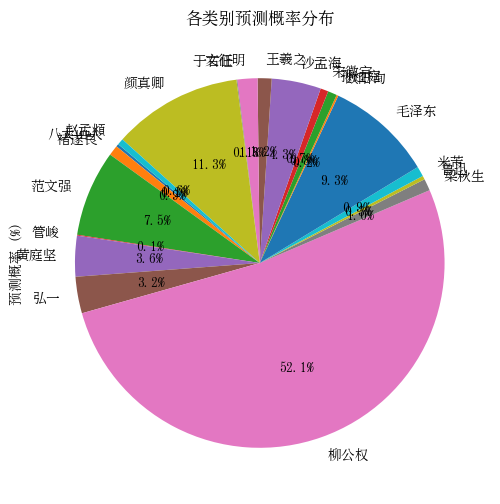

预测类别: lgq (index: 6)
对应书法家: 柳公权


In [11]:
from torch import device
import matplotlib.pyplot as plt
from PIL import Image
device = device("cuda" if torch.cuda.is_available() else "cpu")

image = Image.open("net.png").convert("RGB")
inputs = processor(images=image, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(device)
model.eval()
with torch.no_grad():
    outputs = model(pixel_values=pixel_values)
    logits = outputs.logits
    pred_idx = torch.argmax(logits, dim=1).item()
    pred_label = train_classes[pred_idx]
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy() * 100
    # 画图显示概率分布
    plt.figure(figsize=(10, 6))
    # 中文字体显示
    plt.rcParams["font.sans-serif"] = ["SimSong"]  # 设置中文字体
    # 使用对应作家的中文名字显示
    plt.pie(probs, labels=[master_match_dict.get(c, c) for c in train_classes], autopct="%1.1f%%", startangle=140)
    plt.xticks(rotation=90)
    plt.ylabel("预测概率 (%)")
    plt.title(f"各类别预测概率分布")
    plt.show()

    print(f"预测类别: {pred_label} (index: {pred_idx})")
    print(f"对应书法家: {master_match_dict.get(pred_label, '未知')}")

In [12]:
# 分析模型关注的图像区域：Grad-CAM + Attention Rollout + Saliency
import torch.nn.functional as F
from matplotlib import cm

def normalize_map(x: torch.Tensor) -> torch.Tensor:
    x = x - x.min()
    denom = x.max() - x.min() + 1e-8
    return x / denom

def overlay_heatmap_on_image(image_pil, heatmap_2d, alpha=0.45, cmap_name="jet"):
    img = np.array(image_pil).astype(np.float32) / 255.0
    cmap = cm.get_cmap(cmap_name)
    heat_color = cmap(heatmap_2d)[..., :3]
    overlay = (1 - alpha) * img + alpha * heat_color
    overlay = np.clip(overlay, 0.0, 1.0)
    return overlay

def get_gradcam_map(model, pixel_values, target_idx):
    activations = {}
    gradients = {}

    target_module = model.vit.embeddings.patch_embeddings.projection

    def fwd_hook(_, __, output):
        activations["value"] = output
        output.register_hook(lambda g: gradients.__setitem__("value", g))

    hook = target_module.register_forward_hook(fwd_hook)

    model.zero_grad(set_to_none=True)
    x = pixel_values.clone().detach().requires_grad_(True)
    outputs = model(pixel_values=x)
    score = outputs.logits[:, target_idx].sum()
    score.backward()

    hook.remove()

    if "value" not in gradients:
        raise RuntimeError("Grad-CAM 未捕获到梯度，请确认当前模型与层结构。")

    act = activations["value"]          # [B, C, H, W]
    grad = gradients["value"]           # [B, C, H, W]
    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * act).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
    cam = cam[0, 0]
    cam = normalize_map(cam).detach().cpu().numpy()
    return cam

def get_attention_rollout_map(model, pixel_values):
    with torch.no_grad():
        outputs = model(
            pixel_values=pixel_values,
            output_attentions=True,
            output_hidden_states=True,
            return_dict=True,
        )

    attentions = outputs.attentions  # tuple of [B, heads, tokens, tokens] 或 None

    # 如果拿不到 attentions，则使用最后一层 CLS 与 patch token 的相似度作为替代图
    if attentions is None or len(attentions) == 0 or attentions[0] is None:
        hidden = outputs.hidden_states[-1][0]  # [tokens, hidden_dim]
        cls_token = hidden[0:1]
        patch_tokens = hidden[1:]
        sim = F.cosine_similarity(patch_tokens, cls_token.expand_as(patch_tokens), dim=1)
        side = int(sim.shape[0] ** 0.5)
        sim_map = sim.reshape(side, side).unsqueeze(0).unsqueeze(0)
        sim_map = F.interpolate(sim_map, size=(224, 224), mode="bilinear", align_corners=False)
        sim_map = normalize_map(sim_map[0, 0]).cpu().numpy()
        return sim_map

    rollout = None
    for attn in attentions:
        attn_mean = attn.mean(dim=1)  # [B, T, T]
        eye = torch.eye(attn_mean.size(-1), device=attn_mean.device).unsqueeze(0)
        attn_aug = attn_mean + eye
        attn_aug = attn_aug / attn_aug.sum(dim=-1, keepdim=True)
        rollout = attn_aug if rollout is None else torch.bmm(rollout, attn_aug)

    cls_to_patch = rollout[0, 0, 1:]
    num_patches = cls_to_patch.shape[0]
    side = int(num_patches ** 0.5)
    attn_map = cls_to_patch.reshape(side, side).unsqueeze(0).unsqueeze(0)
    attn_map = F.interpolate(attn_map, size=(224, 224), mode="bilinear", align_corners=False)
    attn_map = normalize_map(attn_map[0, 0]).cpu().numpy()
    return attn_map

def get_input_saliency_map(model, pixel_values, target_idx):
    x = pixel_values.clone().detach().requires_grad_(True)
    model.zero_grad(set_to_none=True)
    outputs = model(pixel_values=x)
    score = outputs.logits[:, target_idx].sum()
    score.backward()

    sal = x.grad.abs().max(dim=1)[0]  # [B, H, W]
    sal = normalize_map(sal[0]).detach().cpu().numpy()
    return sal


/var/folders/hp/r8dplh3n4lx7ljh03b18rq0c0000gn/T/ipykernel_90727/3826107153.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


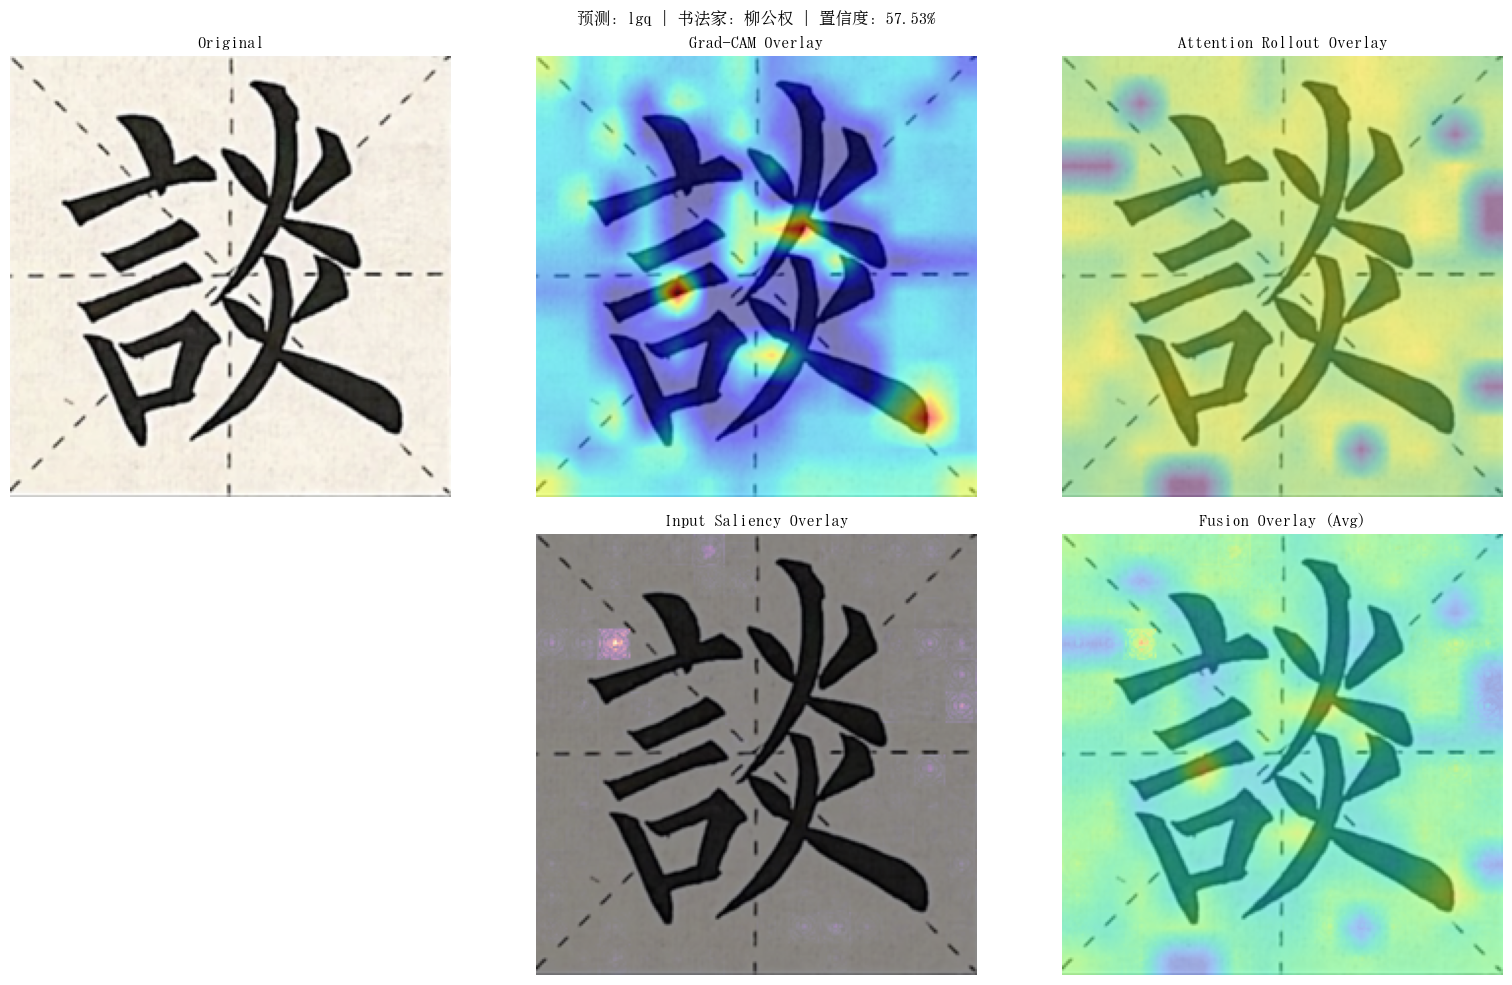

解释提示：
- Grad-CAM 更偏向分类判别的关键笔画区域。
- Attention Rollout 更偏向 Transformer 全局关注路径（若不可用则使用 token 相似度替代）。
- Saliency 显示输入像素微小变化对预测影响的敏感区域。
- Fusion 便于观察三者共同高响应区域，可对应横竖撇捺与转折位置。


In [13]:
# 你可以换成任意图片路径
focus_img_path = "net.png"
focus_image = Image.open(focus_img_path).convert("RGB")
focus_image_224 = focus_image.resize((224, 224))

inputs = processor(images=focus_image_224, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(device)

model.eval()
with torch.no_grad():
    out = model(pixel_values=pixel_values)
    probs = torch.softmax(out.logits, dim=1)[0]
    pred_idx = int(torch.argmax(probs).item())
    pred_label = train_classes[pred_idx]
    pred_prob = float(probs[pred_idx].item() * 100)

gradcam_map = get_gradcam_map(model, pixel_values, pred_idx)
rollout_map = get_attention_rollout_map(model, pixel_values)
saliency_map = get_input_saliency_map(model, pixel_values, pred_idx)
fusion_map = (gradcam_map + rollout_map + saliency_map) / 3.0

overlay_gradcam = overlay_heatmap_on_image(focus_image_224, gradcam_map, alpha=0.50, cmap_name="jet")
overlay_rollout = overlay_heatmap_on_image(focus_image_224, rollout_map, alpha=0.50, cmap_name="viridis")
overlay_saliency = overlay_heatmap_on_image(focus_image_224, saliency_map, alpha=0.45, cmap_name="magma")
overlay_fusion = overlay_heatmap_on_image(focus_image_224, fusion_map, alpha=0.50, cmap_name="turbo")

plt.figure(figsize=(16, 10))
plt.suptitle(f"预测: {pred_label} | 书法家: {master_match_dict.get(pred_label, '未知')} | 置信度: {pred_prob:.2f}%")

plt.subplot(2, 3, 1)
plt.imshow(focus_image_224)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(overlay_gradcam)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(overlay_rollout)
plt.title("Attention Rollout Overlay")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(overlay_saliency)
plt.title("Input Saliency Overlay")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(overlay_fusion)
plt.title("Fusion Overlay (Avg)")
plt.axis("off")

plt.tight_layout()
plt.show()

print("解释提示：")
print("- Grad-CAM 更偏向分类判别的关键笔画区域。")
print("- Attention Rollout 更偏向 Transformer 全局关注路径（若不可用则使用 token 相似度替代）。")
print("- Saliency 显示输入像素微小变化对预测影响的敏感区域。")
print("- Fusion 便于观察三者共同高响应区域，可对应横竖撇捺与转折位置。")